# QTL interval → gene-level table (with SNP IDs per gene) + KEGG enrichment

This notebook does three things:

1) Load QTL interval gene files for **Fluconazole** and **Pulvinatal**.
2) Build a **gene-level dataframe** (one row per gene per interval) and assign a NEW ranked interval ID:
   - `interval_id_ranked = 1` for the interval with the highest `lod_max` (within each drug)
   - then 2, 3, ... in descending LOD order
3) Annotate each gene with the **SNP IDs that fall within that gene**, using:
   `/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/data/snp_info_complete.tsv`

Outputs:
- Gene-level table:
  `/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/qtl_interval_postproc/QTL_gene_level_rankedIntervals_with_geneSNPs.tsv`
- KEGG enrichment results (later section):
  `/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/{DRUG}_interval_{INTERVAL_ID:03d}_KEGG.tsv`

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import requests

# ---------------- INPUT FILES ----------------
FLU_CSV = Path("./data/Fluconazole_QTL_genes_H_20260609.csv")
PUL_CSV = Path("./data/Pulvinatal_QTL_genes_20260520.csv")

SNP_INFO_PATH = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/data/snp_info_complete.tsv")
# ---------------------------------------------

# ---------------- OUTPUT DIRS ----------------
POSTPROC_DIR = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/qtl_interval_postproc")
POSTPROC_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------------------------

# Output file for Task 1
GENE_LEVEL_OUT = POSTPROC_DIR / "QTL_gene_level_rankedIntervals_with_geneSNPs.tsv"

# Sanity checks
for p in [FLU_CSV, PUL_CSV, SNP_INFO_PATH]:
    assert p.exists(), f"Not found: {p}"

print("Inputs:")
print("  FLU:", FLU_CSV)
print("  PUL:", PUL_CSV)
print("  SNP:", SNP_INFO_PATH)
print("\nOutputs:")
print("  POSTPROC_DIR:", POSTPROC_DIR)
print("  RESULTS_DIR :", RESULTS_DIR)
print("  GENE_LEVEL_OUT:", GENE_LEVEL_OUT)

Inputs:
  FLU: data/Fluconazole_QTL_genes_H_20260609.csv
  PUL: data/Pulvinatal_QTL_genes_20260520.csv
  SNP: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/data/snp_info_complete.tsv

Outputs:
  POSTPROC_DIR: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/qtl_interval_postproc
  RESULTS_DIR : /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results
  GENE_LEVEL_OUT: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/qtl_interval_postproc/QTL_gene_level_rankedIntervals_with_geneSNPs.tsv


## Step 1 — Load QTL interval files and assign ranked interval IDs

We load the interval tables for each drug and assign a new interval ID:

- `interval_id_ranked = 1` for the interval with the highest `lod_max`
- then 2, 3, ... in descending `lod_max` order

This ranking is done **within each drug file separately**.

In [5]:
def load_and_rank_intervals(csv_path: Path, drug_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["drug"] = drug_name

    # Required columns (based on your interval export)
    req = ["interval_id", "chrom", "start", "end",
           "genes", "genes_std",
           "pleio_score", "pleio_percentile", "lod_max"]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing required columns: {missing}")

    # Rank intervals by LOD within this drug
    df = df.sort_values(["lod_max", "interval_id"], ascending=[False, True]).reset_index(drop=True)
    df["interval_id_ranked"] = np.arange(1, len(df) + 1)

    # Normalize types
    df["chrom"] = df["chrom"].astype(int)
    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)
    df["lod_max"] = df["lod_max"].astype(float)
    df["pleio_score"] = df["pleio_score"].astype(float)
    df["pleio_percentile"] = df["pleio_percentile"].astype(float)

    return df

flu_int = load_and_rank_intervals(FLU_CSV, "Fluconazole")
pul_int = load_and_rank_intervals(PUL_CSV, "Pulvinatal")

print("Fluconazole intervals:", flu_int.shape)
display(flu_int.head())

print("Pulvinatal intervals:", pul_int.shape)
display(pul_int.head())

Fluconazole intervals: (38, 11)


,interval_id,chrom,start,end,genes,genes_std,pleio_score,pleio_percentile,lod_max,drug,interval_id_ranked
0,14434,7,470529,472821,"YGL013C, YGL012W","PDR1, ERG4",0.015480,80.410563,560.394843,Fluconazole,1
1,14435,7,470529,472821,"YGL013C, YGL012W","PDR1, ERG4",0.015480,80.410563,560.394843,Fluconazole,2
2,14436,7,470529,472821,"YGL013C, YGL012W","PDR1, ERG4",0.015480,80.410563,560.394843,Fluconazole,3
3,34731,14,466098,467214,"YNL087W, YNL086W, YNL085W","TCB2, SNN1, MKT1",0.073915,99.764321,227.170012,Fluconazole,4
4,38631,15,605280,608505,"YOR144C, YOR145C, YOR146W, YOR147W, YOR148C","ELG1, PNO1, PNO1, MDM32, SPP2",0.009331,53.037039,102.679756,Fluconazole,5


Pulvinatal intervals: (127, 11)


,interval_id,chrom,start,end,genes,genes_std,pleio_score,pleio_percentile,lod_max,drug,interval_id_ranked
0,16914,8,121313,122368,"YHR007C, YHR007C-A","ERG11, YHR007C-A",0.007006,37.905407,262.702991,Pulvinatal,1
1,34731,14,466098,468483,"YNL087W, YNL086W, YNL085W","TCB2, SNN1, MKT1",0.431739,100.000000,185.570267,Pulvinatal,2
2,264,1,46030,49403,"YAL053W, YAL051W","FLC2, OAF1",0.035920,98.185543,174.719973,Pulvinatal,3
3,8669,4,1444366,1449613,"YDR496C, YDR497C, YDR498C, YDR499W, YDR500C","PUF6, ITR1, SEC20, LCD1, RPL37B",0.012916,71.157503,132.878854,Pulvinatal,4
4,73,1,29354,59659,"YAL062W, YAL061W, YAL060W, YAL059C-A, YAL059W,...","GDH3, BDH2, BDH1, ECM1, ECM1, CNE1, CNE1, GPB2...",0.040345,98.845711,129.528087,Pulvinatal,5


## Step 2 — Build a gene-level table (one row per gene per interval)

Each QTL interval contains a comma-separated list of genes.
We expand those lists so that the output table has:

- one row per `(drug, interval_id_ranked, gene)`
- interval metadata repeated per gene (chrom/start/end, LOD, pleio metrics)
- both `gene_orf` (systematic ORF) and `gene_std` (standard name, if available)

In [6]:
def split_gene_list(s: str) -> list:
    if pd.isna(s) or str(s).strip() == "":
        return []
    return [x.strip() for x in str(s).split(",") if x.strip()]

def build_gene_level_table(intervals_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, r in intervals_df.iterrows():
        genes_orf = split_gene_list(r["genes"])          # ORFs
        genes_std = split_gene_list(r["genes_std"])      # standard names

        # Keep alignment if possible; otherwise pad standard names
        if len(genes_std) != len(genes_orf):
            genes_std = genes_std + [np.nan] * (len(genes_orf) - len(genes_std))

        for g_orf, g_std in zip(genes_orf, genes_std):
            rows.append({
                "drug": r["drug"],
                "interval_id_original": r["interval_id"],
                "interval_id_ranked": r["interval_id_ranked"],
                "chrom": r["chrom"],
                "start": r["start"],
                "end": r["end"],
                "lod_max": r["lod_max"],
                "pleio_score": r["pleio_score"],
                "pleio_percentile": r["pleio_percentile"],
                "gene_orf": g_orf,
                "gene_std": g_std
            })

    out = pd.DataFrame(rows)

    # Consistent sorting
    out = out.sort_values(
        ["drug", "interval_id_ranked", "chrom", "start", "gene_orf"]
    ).reset_index(drop=True)

    return out

# Combine both drugs into one interval table, then expand
intervals = pd.concat([flu_int, pul_int], ignore_index=True)
gene_df = build_gene_level_table(intervals)

print("Combined intervals:", intervals.shape)
print("Gene-level table:", gene_df.shape)
display(gene_df.head(10))

Combined intervals: (165, 11)
Gene-level table: (4943, 11)


,drug,interval_id_original,interval_id_ranked,chrom,start,end,lod_max,pleio_score,pleio_percentile,gene_orf,gene_std
0,Fluconazole,14434,1,7,470529,472821,560.394843,0.015480,80.410563,YGL012W,ERG4
1,Fluconazole,14434,1,7,470529,472821,560.394843,0.015480,80.410563,YGL013C,PDR1
2,Fluconazole,14435,2,7,470529,472821,560.394843,0.015480,80.410563,YGL012W,ERG4
3,Fluconazole,14435,2,7,470529,472821,560.394843,0.015480,80.410563,YGL013C,PDR1
4,Fluconazole,14436,3,7,470529,472821,560.394843,0.015480,80.410563,YGL012W,ERG4
5,Fluconazole,14436,3,7,470529,472821,560.394843,0.015480,80.410563,YGL013C,PDR1
6,Fluconazole,34731,4,14,466098,467214,227.170012,0.073915,99.764321,YNL085W,MKT1
7,Fluconazole,34731,4,14,466098,467214,227.170012,0.073915,99.764321,YNL086W,SNN1
8,Fluconazole,34731,4,14,466098,467214,227.170012,0.073915,99.764321,YNL087W,TCB2
9,Fluconazole,38631,5,15,605280,608505,102.679756,0.009331,53.037039,YOR144C,ELG1


## Step 3 — Annotate each gene with SNP IDs from `snp_info_complete.tsv`

We load `/blue/.../snp_info_complete.tsv`, which contains:
- SNP ID, chromosome, and position
- gene ORF (`gene_name`) and standard name (`gene_standard_name`)
- gene start/end coordinates

We then build a mapping:
- `gene_orf → comma-separated SNP IDs`
- `gene_orf → number of SNPs`

Finally, we will attach these to the gene-level QTL table.

In [7]:
# Load SNP info table
snp_info = pd.read_csv(SNP_INFO_PATH, sep="\t")
print("Loaded snp_info:", snp_info.shape)
print("Columns:", list(snp_info.columns))

# Standardize column names we will use
snp_info_std = snp_info.rename(columns={
    "SNP": "snp_id",
    "Chromosome": "chrom",
    "Position (bp)": "pos",
    "gene_name": "gene_orf",
    "gene_standard_name": "gene_std",
    "gene_chr_start": "gene_start",
    "gene_chr_end": "gene_end",
    "feature_type": "feature_type",
    "BY allele": "by_allele",
    "RM allele": "rm_allele",
})

# Keep only the columns we care about (and that actually exist)
keep_cols = [c for c in ["snp_id","chrom","pos","gene_orf","gene_std","gene_start","gene_end","feature_type","by_allele","rm_allele"]
             if c in snp_info_std.columns]
snp_info_std = snp_info_std[keep_cols].copy()

# Normalize types
snp_info_std["snp_id"] = snp_info_std["snp_id"].astype(str)
snp_info_std["chrom"] = snp_info_std["chrom"].astype(int)
snp_info_std["pos"] = snp_info_std["pos"].astype(int)
snp_info_std["gene_orf"] = snp_info_std["gene_orf"].astype(str)

display(snp_info_std.head())

# Build gene -> SNP list mapping and gene -> SNP count mapping
gene_to_snps = (
    snp_info_std
    .groupby("gene_orf")["snp_id"]
    .apply(lambda x: ",".join(x.astype(str).tolist()))
    .to_dict()
)

gene_to_nsnps = (
    snp_info_std
    .groupby("gene_orf")["snp_id"]
    .size()
    .to_dict()
)

print("Unique genes with SNP annotations:", len(gene_to_snps))

Loaded snp_info: (41594, 12)
Columns: ['Unnamed: 0', 'Index', 'SNP', 'Chromosome', 'Position (bp)', 'BY allele', 'RM allele', 'feature_type', 'gene_name', 'gene_chr_start', 'gene_chr_end', 'gene_standard_name']


,snp_id,chrom,pos,gene_orf,gene_std,gene_start,gene_end,feature_type,by_allele,rm_allele
0,snp1,1,27210,YAL063C,FLO9,24000,27968,genic,A,G
1,snp2,1,27290,YAL063C,FLO9,24000,27968,genic,C,A
2,snp3,1,27356,YAL063C,FLO9,24000,27968,genic,T,C
3,snp4,1,27357,YAL063C,FLO9,24000,27968,genic,A,G
4,snp5,1,27370,YAL063C,FLO9,24000,27968,genic,G,A


Unique genes with SNP annotations: 5190


## Step 4 — Attach SNP IDs and gene coordinates to each QTL gene row

For each `(drug, interval, gene_orf)` row in the gene-level QTL table, we add:

- `snp_ids_in_gene`: comma-separated SNP IDs that fall within that gene
- `n_snps_in_gene`: number of SNPs in that gene
- `gene_start`, `gene_end`: gene coordinates from `snp_info_complete.tsv`

We also fill missing `gene_std` values using the SNP annotation table.

In [8]:
# Gene metadata (one row per gene_orf; take first SNP row after sorting)
gene_meta = (
    snp_info_std
    .sort_values(["gene_orf", "pos"])
    .groupby("gene_orf", as_index=False)
    .first()[["gene_orf", "gene_std", "gene_start", "gene_end"]]
)

# Attach SNP list and SNP count
gene_df["snp_ids_in_gene"] = gene_df["gene_orf"].map(gene_to_snps).fillna("")
gene_df["n_snps_in_gene"] = gene_df["gene_orf"].map(gene_to_nsnps).fillna(0).astype(int)

# Attach gene coordinates + gene_std (from SNP info)
gene_df = gene_df.merge(gene_meta, on="gene_orf", how="left", suffixes=("", "_from_snpinfo"))

# Fill missing standard names from SNP info (if interval export had blanks)
gene_df["gene_std"] = gene_df["gene_std"].fillna(gene_df["gene_std_from_snpinfo"])

# Clean up helper column
gene_df = gene_df.drop(columns=["gene_std_from_snpinfo"])

print("Updated gene_df:", gene_df.shape)
display(gene_df.head(10))

# Quick sanity check: how many genes got SNPs?
print("Rows with >=1 SNP:", (gene_df["n_snps_in_gene"] > 0).sum(), "/", len(gene_df))

Updated gene_df: (4943, 15)


,drug,interval_id_original,interval_id_ranked,chrom,start,end,lod_max,pleio_score,pleio_percentile,gene_orf,gene_std,snp_ids_in_gene,n_snps_in_gene,gene_start,gene_end
0,Fluconazole,14434,1,7,470529,472821,560.394843,0.015480,80.410563,YGL012W,ERG4,"snp14441,snp14442,snp14443,snp14444,snp14445,s...",7,472855,474276
1,Fluconazole,14434,1,7,470529,472821,560.394843,0.015480,80.410563,YGL013C,PDR1,"snp14428,snp14429,snp14430,snp14431,snp14432,s...",13,469092,472298
2,Fluconazole,14435,2,7,470529,472821,560.394843,0.015480,80.410563,YGL012W,ERG4,"snp14441,snp14442,snp14443,snp14444,snp14445,s...",7,472855,474276
3,Fluconazole,14435,2,7,470529,472821,560.394843,0.015480,80.410563,YGL013C,PDR1,"snp14428,snp14429,snp14430,snp14431,snp14432,s...",13,469092,472298
4,Fluconazole,14436,3,7,470529,472821,560.394843,0.015480,80.410563,YGL012W,ERG4,"snp14441,snp14442,snp14443,snp14444,snp14445,s...",7,472855,474276
5,Fluconazole,14436,3,7,470529,472821,560.394843,0.015480,80.410563,YGL013C,PDR1,"snp14428,snp14429,snp14430,snp14431,snp14432,s...",13,469092,472298
6,Fluconazole,34731,4,14,466098,467214,227.170012,0.073915,99.764321,YNL085W,MKT1,"snp34731,snp34732,snp34733,snp34734",4,467131,469623
7,Fluconazole,34731,4,14,466098,467214,227.170012,0.073915,99.764321,YNL086W,SNN1,snp34730,1,466334,466642
8,Fluconazole,34731,4,14,466098,467214,227.170012,0.073915,99.764321,YNL087W,TCB2,"snp34720,snp34721,snp34722,snp34723,snp34724,s...",10,462411,465947
9,Fluconazole,38631,5,15,605280,608505,102.679756,0.009331,53.037039,YOR144C,ELG1,"snp38606,snp38607,snp38608,snp38609,snp38610,s...",21,602717,605092


Rows with >=1 SNP: 4943 / 4943


## Step 5 — Save the gene-level QTL table (with SNP IDs per gene)

We now save the final gene-level table to:

`/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/qtl_interval_postproc/QTL_gene_level_rankedIntervals_with_geneSNPs.tsv`

This file is the input for the KEGG enrichment section that follows.

In [9]:
gene_df.to_csv(GENE_LEVEL_OUT, sep="\t", index=False)
print("Saved:", GENE_LEVEL_OUT.resolve())

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/qtl_interval_postproc/QTL_gene_level_rankedIntervals_with_geneSNPs.tsv


# KEGG enrichment (user-selected drug + ranked interval)

User-defined variables:
1) `DRUG` — either `"Fluconazole"` or `"Pulvinatal"`
2) `INTERVAL_ID` — ranked interval ID (1 = highest LOD within that drug, then 2, 3, ...)

We will:
- subset the gene-level table to the selected `(DRUG, INTERVAL_ID)`
- extract genes (standard names by default)
- run KEGG enrichment using g:Profiler
- save results to:
  `/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results`

In [15]:
# ---------------- USER INPUTS ----------------
DRUG = "Fluconazole"   # "Fluconazole" or "Pulvinatal"
INTERVAL_ID = 5        # ranked interval ID (1 = highest LOD)
USE_STD_NAMES = False   # True uses gene_std, False uses gene_orf
FDR = 0.05             # g:Profiler user_threshold
# ---------------------------------------------

# Reload from disk to ensure this section is standalone
gene_df_kegg = pd.read_csv(GENE_LEVEL_OUT, sep="\t")

sub = gene_df_kegg[(gene_df_kegg["drug"] == DRUG) & (gene_df_kegg["interval_id_ranked"] == INTERVAL_ID)]
if sub.empty:
    raise ValueError(f"No rows found for DRUG={DRUG}, interval_id_ranked={INTERVAL_ID}")

# interval-level summary (same per gene; show once)
summary_cols = ["drug","interval_id_ranked","interval_id_original","chrom","start","end","lod_max","pleio_score","pleio_percentile"]
interval_summary = sub[summary_cols].drop_duplicates().reset_index(drop=True)
display(interval_summary)

# gene list for enrichment
gene_col = "gene_std" if USE_STD_NAMES else "gene_orf"
genes = sub[gene_col].dropna().astype(str).unique().tolist()
genes = [g for g in genes if g and g.lower() != "nan"]

print("Using column:", gene_col)
print("Number of genes:", len(genes))
print("First 30 genes:", genes[:30])

if len(genes) < 3:
    raise ValueError("Too few genes for enrichment. Try another interval or set USE_STD_NAMES=False.")

,drug,interval_id_ranked,interval_id_original,chrom,start,end,lod_max,pleio_score,pleio_percentile
0,Fluconazole,5,38631,15,605280,608505,102.679756,0.009331,53.037039


Using column: gene_orf
Number of genes: 5
First 30 genes: ['YOR144C', 'YOR145C', 'YOR146W', 'YOR147W', 'YOR148C']


## Step 6 — Run KEGG enrichment and add `qtl_gene` using KEGG REST

This g:Profiler API deployment does not return overlapping genes per term (its `query` field is only a label like `query_1`).
So we:

1) Run g:Profiler KEGG enrichment and keep the results in their native format.
2) For each returned KEGG pathway (`native` like `KEGG:00600`), query **KEGG REST** to fetch member genes.
3) Compute:
   `qtl_gene = (QTL query genes) ∩ (genes in that KEGG pathway)`
4) Store `qtl_gene` as comma-separated genes and place it immediately after `name`.

Output is saved to:
`/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results`

Filename:
`{DRUG}_interval_{INTERVAL_ID:03d}_KEGG.tsv`

In [16]:
import re
import time

def gprofiler_kegg_native(gene_list, organism="scerevisiae", fdr=0.05):
    url = "https://biit.cs.ut.ee/gprofiler/api/gost/profile/"
    payload = {
        "organism": organism,
        "query": gene_list,
        "sources": ["KEGG"],
        "user_threshold": fdr,
        "all_results": True,
        "no_evidences": True
    }

    r = requests.post(url, json=payload, timeout=120)
    if r.status_code != 200:
        print("Status:", r.status_code)
        print("Response text:\n", r.text[:2000])
        r.raise_for_status()

    js = r.json()
    return pd.DataFrame(js.get("result", []))

def kegg_native_to_sce_pathway(native_id: str) -> str:
    """
    Convert g:Profiler native like 'KEGG:00600' -> KEGG pathway id 'sce00600'
    """
    if not isinstance(native_id, str):
        return None
    m = re.search(r"KEGG:(\d+)", native_id)
    if not m:
        return None
    return f"sce{m.group(1)}"

def fetch_kegg_pathway_genes_sce(sce_pathway: str) -> set:
    """
    Use KEGG REST to get genes linked to a pathway.
    Example:
      http://rest.kegg.jp/link/sce/pathway:sce00600
    Returns a set of ORF systematic names like YAL063C, etc.
    """
    if sce_pathway is None:
        return set()

    url = f"http://rest.kegg.jp/link/sce/pathway:{sce_pathway}"
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        return set()

    genes = set()
    text = r.text.strip()
    if not text:
        return set()

    # Lines look like: pathway:sce00600   sce:YAL063C
    for line in text.splitlines():
        parts = line.split("\t")
        if len(parts) != 2:
            continue
        gene_part = parts[1]
        if ":" in gene_part:
            genes.add(gene_part.split(":", 1)[1].strip())
        else:
            genes.add(gene_part.strip())

    return genes

def add_qtl_gene_via_kegg_rest(df: pd.DataFrame, query_genes: list) -> pd.DataFrame:
    """
    Add qtl_gene by intersecting query_genes (ORFs) with KEGG pathway gene members fetched via KEGG REST.
    Requires df to have 'native' (e.g., KEGG:00600) and 'name'.
    """
    if df.empty:
        df = df.copy()
        df["qtl_gene"] = []
        return df

    if "native" not in df.columns:
        df = df.copy()
        df["qtl_gene"] = ""
        print("WARNING: No 'native' column in results; cannot fetch KEGG pathway genes.")
        return df

    query_set = set([g.strip() for g in query_genes if g and str(g).strip()])
    cache = {}

    qtl_gene_col = []
    for _, row in df.iterrows():
        native_id = row.get("native", None)
        sce_pathway = kegg_native_to_sce_pathway(native_id)

        if sce_pathway not in cache:
            cache[sce_pathway] = fetch_kegg_pathway_genes_sce(sce_pathway)
            time.sleep(0.1)

        pathway_genes = cache.get(sce_pathway, set())
        overlap = sorted(query_set.intersection(pathway_genes))
        qtl_gene_col.append(",".join(overlap))

    df = df.copy()
    df["qtl_gene"] = qtl_gene_col

    # Insert qtl_gene immediately after name
    if "name" in df.columns:
        cols = list(df.columns)
        cols.remove("qtl_gene")
        name_idx = cols.index("name")
        cols.insert(name_idx + 1, "qtl_gene")
        df = df[cols]

    return df

# 1) Get native API results
enr_native = gprofiler_kegg_native(genes, organism="scerevisiae", fdr=FDR)

# Remove meaningless KEGG root term safely
if not enr_native.empty and "native" in enr_native.columns:
    enr_native = enr_native[enr_native["native"] != "KEGG:00000"].reset_index(drop=True)

print("KEGG terms returned:", len(enr_native))
print("Columns returned by API:\n", list(enr_native.columns))

# 2) Add qtl_gene using KEGG REST overlap
# IMPORTANT: This assumes `genes` are ORFs (Yxxx...). If you used standard names, set USE_STD_NAMES=False upstream.
enr = add_qtl_gene_via_kegg_rest(enr_native, genes)

display(enr.head(25))

# 3) Save only if there are KEGG terms
if len(enr) == 0:
    print(f"[SKIP] {DRUG} interval {INTERVAL_ID}: no KEGG terms returned after filtering")
else:
    out_path = RESULTS_DIR / f"{DRUG}_interval_{INTERVAL_ID:03d}_KEGG.tsv"
    enr.to_csv(out_path, sep="\t", index=False)
    print("Saved:", out_path.resolve())

KEGG terms returned: 1
Columns returned by API:
 ['description', 'effective_domain_size', 'goshv', 'intersection_size', 'name', 'native', 'p_value', 'parents', 'precision', 'query', 'query_size', 'recall', 'significant', 'source', 'term_size', 'source_order', 'group_id']


,description,effective_domain_size,goshv,intersection_size,name,qtl_gene,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,source_order,group_id
0,Spliceosome,2248,38958,1,Spliceosome,YOR148C,KEGG:03040,0.409852,[KEGG:00000],1.0,query_1,1,0.012195,False,KEGG,82,220,1


Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_interval_005_KEGG.tsv


In [17]:
pd.set_option("display.max_colwidth", 200)
display(enr)

,description,effective_domain_size,goshv,intersection_size,name,qtl_gene,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,source_order,group_id
0,Spliceosome,2248,38958,1,Spliceosome,YOR148C,KEGG:03040,0.409852,[KEGG:00000],1.0,query_1,1,0.012195,False,KEGG,82,220,1


# Optional: Batch mode KEGG enrichment (multiple intervals)

This section runs KEGG enrichment for multiple ranked intervals in one go.

User inputs:
- `DRUG` (same as before)
- `INTERVAL_IDS` (a list of ranked interval IDs, e.g. [1,2,3])
- `MIN_GENES` to skip very small gene sets

Output:
- One TSV per interval saved to:
  `/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results`
- Filename:
  `{DRUG}_interval_{INTERVAL_ID:03d}_KEGG.tsv`

Each output includes:
- `qtl_gene` column (comma-separated query genes overlapping each KEGG term)

In [18]:
# ---------------- BATCH USER INPUTS ----------------
DRUG = "Fluconazole"          # "Fluconazole" or "Pulvinatal"
USE_STD_NAMES = False         # MUST be False here (ORFs), since KEGG REST returns ORFs
FDR = 0.05
MIN_GENES = 3                 # skip intervals with fewer genes than this
# ---------------------------------------------------

gene_df_kegg = pd.read_csv(GENE_LEVEL_OUT, sep="\t")

# Automatically detect all ranked intervals for this drug
max_interval = gene_df_kegg[gene_df_kegg["drug"] == DRUG]["interval_id_ranked"].max()
INTERVAL_IDS = list(range(1, max_interval + 1))
print("Running intervals:", INTERVAL_IDS)

gene_col = "gene_std" if USE_STD_NAMES else "gene_orf"

batch_summary = []
kegg_cache = {}  # cache pathway -> gene set across all intervals

def fetch_kegg_pathway_genes_sce_cached(sce_pathway: str) -> set:
    if sce_pathway in kegg_cache:
        return kegg_cache[sce_pathway]
    geneset = fetch_kegg_pathway_genes_sce(sce_pathway)
    kegg_cache[sce_pathway] = geneset
    return geneset

def add_qtl_gene_via_kegg_rest_cached(df: pd.DataFrame, query_genes: list, gene_df_kegg: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        df = df.copy()
        df["qtl_gene"] = []
        df["gene_std"] = []
        return df

    # mapping ORF -> standard gene name
    orf_to_std = dict(
        gene_df_kegg[["gene_orf", "gene_std"]]
        .drop_duplicates()
        .values
    )

    query_set = set([g.strip() for g in query_genes if g and str(g).strip()])

    qtl_gene_col = []
    std_gene_col = []

    for _, row in df.iterrows():
        native_id = row.get("native", None)
        sce_pathway = kegg_native_to_sce_pathway(native_id)

        pathway_genes = fetch_kegg_pathway_genes_sce_cached(sce_pathway)
        overlap_orf = sorted(query_set.intersection(pathway_genes))

        # ORF names
        qtl_gene_col.append(",".join(overlap_orf))

        # Standard names
        std_names = [orf_to_std.get(g, "") for g in overlap_orf]
        std_names = [g for g in std_names if g != ""]
        std_gene_col.append(",".join(std_names))

    df = df.copy()
    df["qtl_gene"] = qtl_gene_col
    df["gene_std"] = std_gene_col

    # Insert columns immediately after "name"
    if "name" in df.columns:
        cols = list(df.columns)
        cols.remove("qtl_gene")
        cols.remove("gene_std")

        name_idx = cols.index("name")
        cols.insert(name_idx + 1, "qtl_gene")
        cols.insert(name_idx + 2, "gene_std")

        df = df[cols]

    return df

for iid in INTERVAL_IDS:
    sub = gene_df_kegg[
        (gene_df_kegg["drug"] == DRUG) &
        (gene_df_kegg["interval_id_ranked"] == iid)
    ]

    if sub.empty:
        print(f"[SKIP] {DRUG} interval {iid}: not found")
        batch_summary.append({
            "drug": DRUG,
            "interval_id_ranked": iid,
            "status": "not_found",
            "n_genes": 0,
            "n_kegg_terms": 0
        })
        continue

    genes_i = sub[gene_col].dropna().astype(str).unique().tolist()
    genes_i = [g.strip() for g in genes_i if g and g.lower() != "nan"]
    n_genes = len(genes_i)

    if n_genes < MIN_GENES:
        print(f"[SKIP] {DRUG} interval {iid}: too few genes ({n_genes})")
        batch_summary.append({
            "drug": DRUG,
            "interval_id_ranked": iid,
            "status": "too_few_genes",
            "n_genes": n_genes,
            "n_kegg_terms": 0
        })
        continue

    # 1) native g:Profiler results
    enr_native_i = gprofiler_kegg_native(genes_i, organism="scerevisiae", fdr=FDR)

    # Remove meaningless KEGG root term safely
    if not enr_native_i.empty and "native" in enr_native_i.columns:
        enr_native_i = enr_native_i[enr_native_i["native"] != "KEGG:00000"].reset_index(drop=True)

    n_native = len(enr_native_i)

    # 2) add qtl_gene + gene_std via KEGG REST overlap
    enr_i = add_qtl_gene_via_kegg_rest_cached(enr_native_i, genes_i, gene_df_kegg)
    n_terms = len(enr_i)

    # 3) save only if at least one KEGG term remains
    if n_terms == 0:
        print(f"[SKIP] {DRUG} interval {iid}: no KEGG terms returned")
        batch_summary.append({
            "drug": DRUG,
            "interval_id_ranked": iid,
            "status": "no_terms",
            "n_genes": n_genes,
            "n_kegg_terms": 0,
            "n_api_terms": n_native
        })
    else:
        out_path = RESULTS_DIR / f"{DRUG}_interval_{iid:03d}_KEGG.tsv"
        enr_i.to_csv(out_path, sep="\t", index=False)

        print(f"[OK] {DRUG} interval {iid}: genes={n_genes}, KEGG_terms={n_terms} -> {out_path.name}")
        batch_summary.append({
            "drug": DRUG,
            "interval_id_ranked": iid,
            "status": "ok",
            "n_genes": n_genes,
            "n_kegg_terms": n_terms,
            "outfile": str(out_path),
            "n_api_terms": n_native
        })

batch_summary_df = pd.DataFrame(batch_summary)
display(batch_summary_df)

Running intervals: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
[SKIP] Fluconazole interval 1: too few genes (2)
[SKIP] Fluconazole interval 2: too few genes (2)
[SKIP] Fluconazole interval 3: too few genes (2)
[SKIP] Fluconazole interval 4: no KEGG terms returned
[OK] Fluconazole interval 5: genes=5, KEGG_terms=1 -> Fluconazole_interval_005_KEGG.tsv
[OK] Fluconazole interval 6: genes=3, KEGG_terms=3 -> Fluconazole_interval_006_KEGG.tsv
[OK] Fluconazole interval 7: genes=5, KEGG_terms=8 -> Fluconazole_interval_007_KEGG.tsv
[OK] Fluconazole interval 8: genes=4, KEGG_terms=2 -> Fluconazole_interval_008_KEGG.tsv
[OK] Fluconazole interval 9: genes=12, KEGG_terms=4 -> Fluconazole_interval_009_KEGG.tsv
[OK] Fluconazole interval 10: genes=14, KEGG_terms=5 -> Fluconazole_interval_010_KEGG.tsv
[OK] Fluconazole interval 11: genes=14, KEGG_terms=5 -> Fluconazole_interval_011_KEGG.tsv
[OK] Fluconazol

,drug,interval_id_ranked,status,n_genes,n_kegg_terms,n_api_terms,outfile
0,Fluconazole,1,too_few_genes,2,0,NaN,NaN
1,Fluconazole,2,too_few_genes,2,0,NaN,NaN
2,Fluconazole,3,too_few_genes,2,0,NaN,NaN
3,Fluconazole,4,no_terms,3,0,0.0,NaN
4,Fluconazole,5,ok,5,1,1.0,/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_interval_005_KEGG.tsv
5,Fluconazole,6,ok,3,3,3.0,/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_interval_006_KEGG.tsv
6,Fluconazole,7,ok,5,8,8.0,/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_interval_007_KEGG.tsv
7,Fluconazole,8,ok,4,2,2.0,/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_interval_008_KEGG.tsv
8,Fluconazole,9,ok,12,4,4.0,/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_interval_009_KEGG.tsv
9,Fluconazole,10,ok,14,5,5.0,/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_interval_010_KEGG.tsv


# Visualize KEGG enrichment across intervals

We construct a matrix:

Rows = interval_id_ranked  
Columns = KEGG pathways  
Values = -log10(p_value)

Then perform hierarchical clustering and show a heatmap.

Found 32 KEGG result files for Fluconazole
Matrix shape: (32, 42)
Plot saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/results/Fluconazole_KEGG_interval_clustermap.png


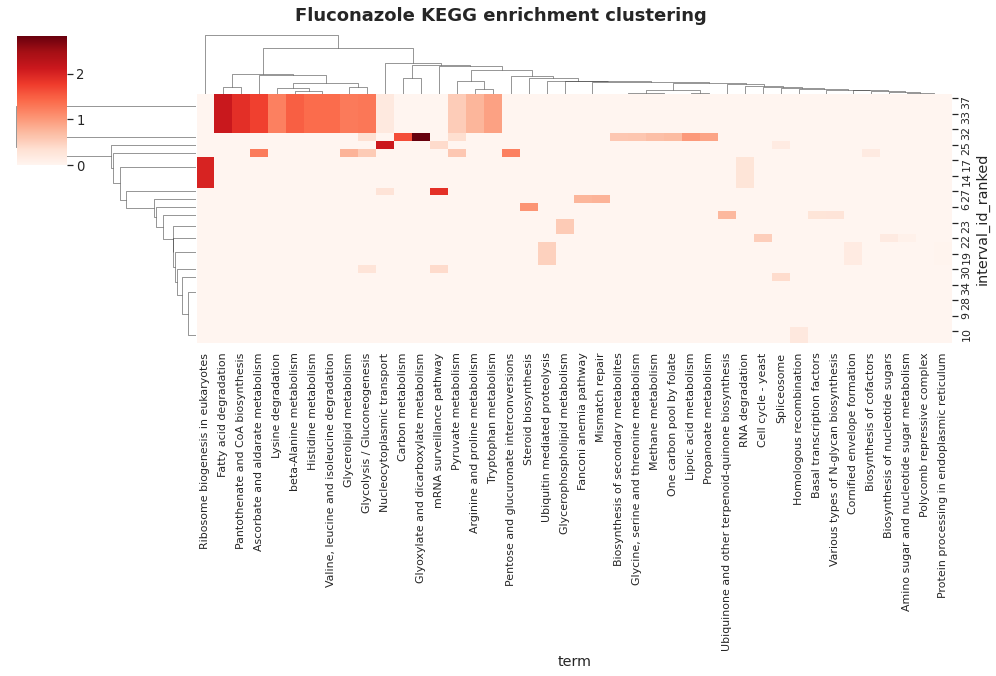

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
from pathlib import Path
import pandas as pd

# ---- SETTINGS ----
DRUG = "Fluconazole"   # "Fluconazole" or "Pulvinatal"
RESULTS_PATH = RESULTS_DIR
REMOVE_ROOT_TERM = True
MINUS_LOG10_CAP = None   # e.g. set to 10 if you want to cap extreme values
# ------------------

# Collect all KEGG files for this drug
files = sorted(glob.glob(str(RESULTS_PATH / f"{DRUG}_interval_*_KEGG.tsv")))
print(f"Found {len(files)} KEGG result files for {DRUG}")

if len(files) == 0:
    print(f"No KEGG result files found for {DRUG} in {RESULTS_PATH}")
else:
    records = []

    for f in files:
        iid = int(Path(f).stem.split("_")[2])  # extract ranked interval ID
        df = pd.read_csv(f, sep="\t")

        if df.empty:
            continue

        # Safety filter in case root term still exists in some files
        if REMOVE_ROOT_TERM and "native" in df.columns:
            df = df[df["native"] != "KEGG:00000"].copy()

        if df.empty:
            continue

        for _, row in df.iterrows():
            p = row.get("p_value", None)
            term = row.get("name", None)

            if pd.isna(p) or pd.isna(term):
                continue
            if p <= 0:
                value = 0
            else:
                value = -np.log10(p)

            if MINUS_LOG10_CAP is not None:
                value = min(value, MINUS_LOG10_CAP)

            records.append({
                "interval_id_ranked": iid,
                "term": str(term),
                "value": value
            })

    heat_df = pd.DataFrame(records)

    if heat_df.empty:
        print(f"No usable KEGG terms found for {DRUG} after filtering.")
    else:
        # Pivot to interval x term matrix
        matrix = heat_df.pivot_table(
            index="interval_id_ranked",
            columns="term",
            values="value",
            fill_value=0
        )

        # Sort intervals numerically
        matrix = matrix.sort_index()

        # Remove columns that are zero everywhere
        matrix = matrix.loc[:, (matrix != 0).any(axis=0)]

        print("Matrix shape:", matrix.shape)

        if matrix.shape[1] == 0:
            print(f"No non-zero KEGG terms remain for {DRUG}.")
        else:
            sns.set_style("white")
            sns.set_context("talk")
            sns.set(font_scale=1.2)

            g = sns.clustermap(
                matrix,
                cmap="Reds",
                figsize=(14, 10),
                standard_scale=None
            )

            g.fig.suptitle(
                f"{DRUG} KEGG enrichment clustering",
                fontsize=18,
                fontweight="bold",
                y=1.02
            )

            # Optional: improve tick label readability
            g.ax_heatmap.set_xticklabels(
                g.ax_heatmap.get_xticklabels(),
                rotation=90,
                fontsize=11
            )
            g.ax_heatmap.set_yticklabels(
                g.ax_heatmap.get_yticklabels(),
                fontsize=11
            )

            # Save figure
            plot_path = RESULTS_DIR / f"{DRUG}_KEGG_interval_clustermap.png"
            g.fig.savefig(plot_path, dpi=300, bbox_inches="tight")

            print("Plot saved to:", plot_path.resolve())
            plt.show()